# Energy resolution for an X-ray detector
## Definition of energy resolution
Here we define the energy resolution function for a scintillator,
    but analogous definitions can be made for other types of X-ray or gamma detectors.

Based on the physics of scintillation and the relative contributions of different error types,
    the scintillation energy resolution can usually be written as follows:
$$
    R(E) = \frac{\alpha}{\sqrt{E}}
$$

Where $R$ is in percent, $E$ is the energy, and $\alpha$,
    units [percent / sqrt energy],
    is a scaling factor determined by the scintillator properties.

More complicated or customized functions can be swapped out depending on science and accuracy requirements.

## Measure the energy resolution
Energy resolution is measured from radioactive source data.
It is sometimes a function of temperature and other external factors,
    so this needs to get calibrated.
For a constant temperature, bias voltage, crystal geometry, readout chain, etc.,
    the energy resolution is only a function of the physical layout of the detector.

We fit a Gaussian function to the line of the form
$$
f(E) = A \exp\left( - \left[ \frac{(E - \mu)}{\sigma} \right]^2 \right)
$$

$A$, $\sigma$, and $\mu$ are free parameters.
The fit range is important here because the peak is usually skewed,
    either by a Compton scattering tail,
    or by other emission leaking in.
The scaling parameter $A$ has units of [1 / energy] so that $f(E)$ can be normalized to be a probability density.

For this Gaussian form, the FWHM as a fraction of the mean is
$$
\text{FWHM} = \frac{2 \sigma \sqrt{\ln 2}}{\mu}
$$

**This is different from what you will find on Wikipedia**
because there is no factor of 2 in the denominator of the Gaussian argument.

To obtain $\alpha$ for $R(E)$,
    we fit a curve to several measured values of the FWHM across different energies.

## Applying energy resolution to a detector response
### Formalism: a continuous response
The energy resolution should be applied as a convolution.
Say that the $j^\text{th}$ column of an energy redistribution matrix is represented by the continuous function $r_j(E)$.
You could compute this function from a set of mass attenuation coefficients.
The continuous function $r_j(E)$ describes the probability _density_ of converting an incident photon to a count,
    and has units of [count / photon / energy].
Then to apply the energy resolution to this column, we would write
$$
r^*_j(E) = \int_{-\infty}^{\infty} r_j(E - \varepsilon) f_j(\varepsilon)\ \mathrm d \varepsilon.
$$

$f_j(\varepsilon)$ is the Gaussian function defined above,
    normalized so that its area is 1,
    where the index $j$ determines the values of $\sigma$ and $\mu$.
The integration bounds are truncated by the response matrix energy bounds,
    so we write
$$
r^*_j(E) = \int_{E_0}^{E_N} r_j(E - \varepsilon) f_j(\varepsilon)\ \mathrm d \varepsilon,
$$

where $E_0$ is the leftmost energy bin edge,
    and $E_N$ is the rightmost energy bin edge.

For a properly normalized $f_j(\varepsilon)$,
    the total probability contained in the function $r_j(E)$ is conserved in the full convolution integral,
    and is truncated for the finite bounds.
This truncation is what we want for the response matrix,
    and encodes when a detected count energy falls outside of the bounds of the instrument.

### Application: binned data
For binned data (e.g. count bins and a pixellated response matrix),
    we can apply the convolution in a different way.

Here we construct a discretely-indexed response matrix $r_{ij}$ rather than a set of continuous functions $r_j$.
Each pixel $r_{ij}$ in the response matrix holds the probability
    of converting a photon between energies $[E_{i}, E_{i + 1}]$ to a count between those same energies;
    the photon energies $E_i$ run along the rows of the matrix.
To convert the continuous functions $r_j(E)$ to matrix elements,
    we write
$$
    r_{ij} = \int_{E_i}^{E_{i + 1}} r_j(E)\ \mathrm d E.
$$

For small $\Delta E = E_b - E_a$,
    and smooth $r_j$,
    the integral can be approximated as its midpoint Riemann sum,
    $r_{ij} = \Delta E \times r_i((E_b - E_a) / 2)$.
> **Note:** sometimes $r_j$ has sharp features in photon detectors at absorption edges.
> Be careful when applying the midpoint approximation.

We also construct an energy resolution matrix $f_{ij}$.
The rows of $f_{ij}$ are pixellated Gaussians;
    the photon energies run along the columns.
Say the $j^\text{th}$ column is bounded by the energy bin $[E_j, E_{j+1}]$.
Then
$$
    f_{ij} = \int_{E_j}^{E_{j+1}} f_i(E)\ \mathrm d E.
$$

Because the Gaussian integral has a [well-known solution](https://en.wikipedia.org/wiki/Error_function),
    we can write
$$
    f_{ij} = \frac{1}{2}\left[
        \mathrm{erf}\left(\frac{E_{j+1} - \mu_i}{\sigma_i}\right) -
        \mathrm{erf}\left(\frac{E_j - \mu_i}{\sigma_i}\right)
    \right].
$$

To convolve this energy resolution matrix with the energy redistribution matrix,
    we just multiply them.
So the total response matrix is
$$
    r^*_{ij} = f_{ij} r_{ij}.
$$
The $i^\text{th}$ **row** of $f_{ij}$ is the pixellated Gaussian,
    and the $j^\text{th}$ **column** of $r_{ij}$ is the count to photon conversion probability.

### The matrix $r^*_{ij}$ is the resolution-applied response matrix.

# Code: energy resolution for a scintillation detector

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.visualization import quantity_support

from adetsim import detection

%matplotlib inline
plt.style.use("nice.mplstyle")

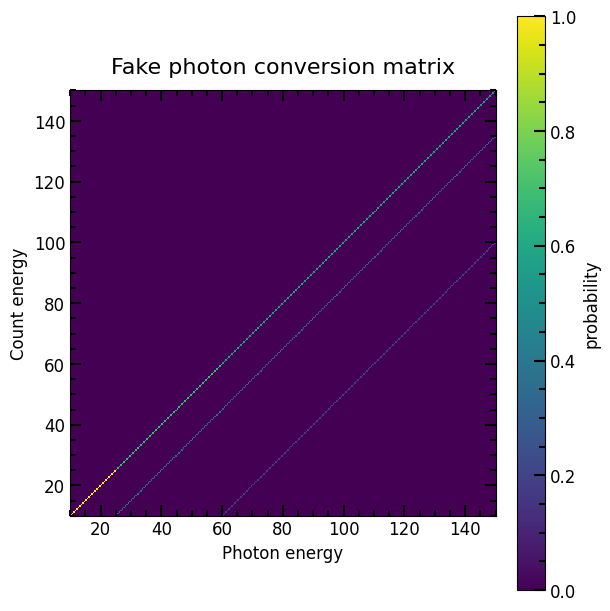

In [2]:
# Construct photon energy bins
de = 0.5
bins = np.arange(10, 150 + de, de)
size = bins.size - 1

# Make a fake redistribution matrix with some off-diagonal terms
example = np.eye(size)
np.fill_diagonal(example[:, 30:], 0.5)
np.fill_diagonal(example[:, 100:], 0.3)

# The probabilities should still sum to <= 1 along each column: we have escape peaks now
example = example / example.sum(axis=0)

fig, ax = plt.subplots(figsize=(6, 6))
pcm = ax.pcolormesh(bins, bins, example)
ax.set_aspect(1)
ax.set(
    aspect=1,
    title="Fake photon conversion matrix",
    xlabel="Photon energy",
    ylabel="Count energy"
)
fig.colorbar(pcm, label='probability')
plt.show()

In [3]:
# The energies and FWHMs that we will fit.
# These actually correspond to a YAP scintillator. Not bad!
energies = [31, 60, 122] << u.keV
fwhms = [27.5, 18, 13] << u.percent
# Assume 5% uniform error on the FWHMs
fwhm_error = fwhms * 0.05

# The data are automatically fitted with the ~ 1/sqrt(E) function
ereln = detection.SqrtEnergyResolution(
    reference_fwhms=fwhms, fwhm_errors=fwhm_error, reference_energies=energies
)

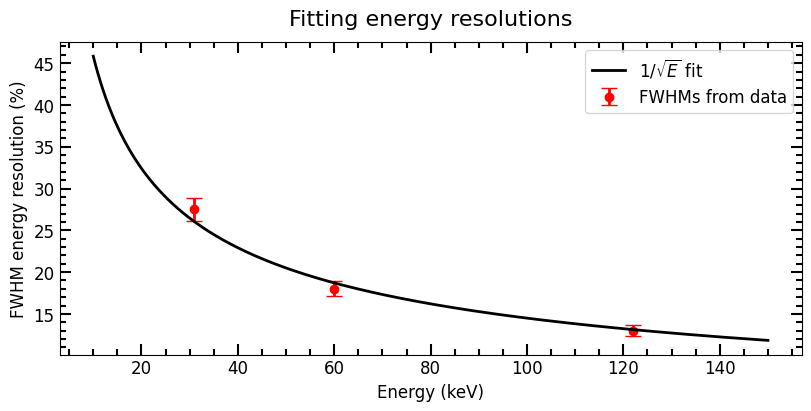

In [4]:
# Plot the energy resolution function to see how good the fit is
fig, ax = plt.subplots()

with quantity_support():
    ax.errorbar(
        energies,
        fwhms,
        yerr=fwhm_error,
        color="red",
        label="FWHMs from data",
        marker=".",
        ms=12,
        capsize=6,
        ls="None",
        zorder=-1,
    )

energy_range = bins
ax.plot(
    energy_range,
    # Evaluate the energy resolution (convert it to percent)
    100 * ereln.resolution_function(energy_range),
    label=r"$1 / \sqrt{E}$ fit",
    color="black",
)

ax.legend()
ax.set(
    ylabel="FWHM energy resolution (%)",
    xlabel="Energy (keV)",
    title="Fitting energy resolutions",
)

plt.show()

In [5]:
# Compute the resolution matrix f_ij
resolution_matrix = ereln.generate_resolution_matrix(bins << u.keV)

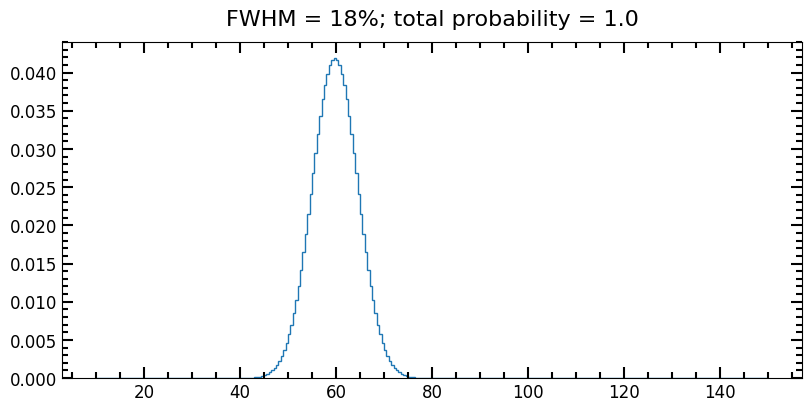

In [6]:
# Double check that we have ~the same resolution in the matrix
# as we do in the data we supplied
mids = bins[:-1] + np.diff(bins) / 2
# Look at the 60 keV number
idx = np.argmin(np.abs(mids - 60))
test = resolution_matrix[idx]

max_idx = test.argmax()
top_idx = np.argmin(np.abs(test - (test.max() / 2)))
fwhm = 2 * (mids[max_idx] - mids[top_idx]) / mids[max_idx]

fig, ax = plt.subplots()
ax.stairs(test, bins)
ax.set(title=f"FWHM = {100 * fwhm:.0f}%; total probability = {test.sum():.1f}")
plt.show()

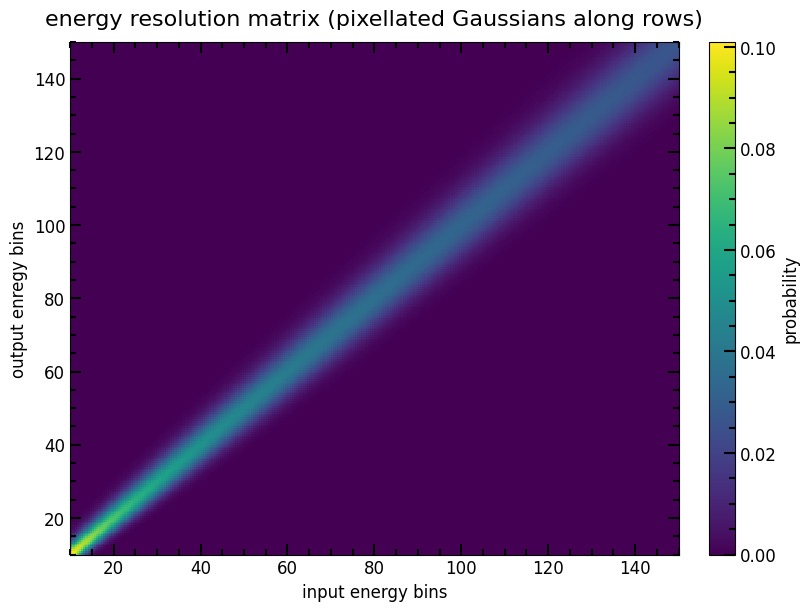

In [7]:
# Plot the resolution matrix
fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(energy_range, energy_range, resolution_matrix)
ax.set(
    xlabel="input energy bins",
    ylabel="output enregy bins",
    title="energy resolution matrix (pixellated Gaussians along rows)",
)
_ = fig.colorbar(pcm, label="probability")
plt.show()

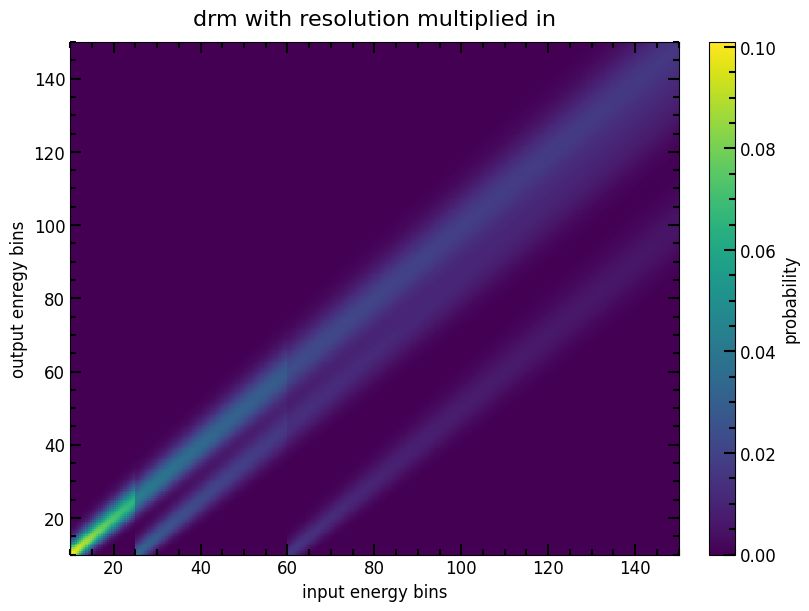

In [8]:
# Plot the resolution matrix multiplied into the redistribution matrix
fig, ax = plt.subplots(figsize=(8, 6))
pcm = ax.pcolormesh(energy_range, energy_range, (drm := resolution_matrix @ example))
ax.set(
    xlabel="input energy bins",
    ylabel="output enregy bins",
    title="drm with resolution multiplied in",
)
_ = fig.colorbar(pcm, label="probability")
plt.show()

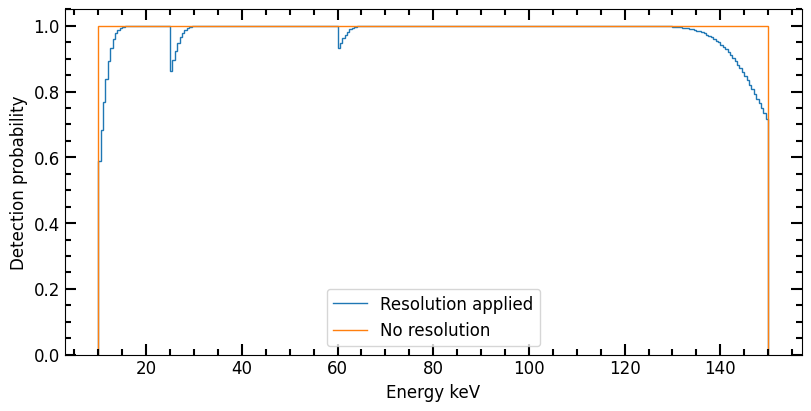

In [9]:
# Look at the effect of the energy resolution on the absorption edges,
# and the edges of the energy range

fig, ax = plt.subplots()
ax.stairs(drm.sum(axis=0), energy_range, label="Resolution applied")
ax.stairs(example.sum(axis=0), energy_range, label="No resolution")
ax.set(xlabel="Energy keV", ylabel="Detection probability")
ax.legend()
plt.show()